In [1]:
import numpy as np
import pandas as pd



In [2]:
import matplotlib.pyplot as plt

In [3]:
#Exploratory Data Analysis

In [4]:
url = "https://s3.amazonaws.com/projex.dezyre.com/multiple-linear-regression-project-for-beginners/materials/EPL_Soccer_MLR_LR.csv"
df = pd.read_csv(url)

In [5]:
df.head()

,PlayerName,Club,DistanceCovered(InKms),Goals,MinutestoGoalRatio,ShotsPerGame,AgentCharges,BMI,Cost,PreviousClubCost,Height,Weight,Score
0,"Braund, Mr. Owen Harris",MUN,3.96,7.5,37.5,12.3,60,20.56,109.1,63.32,195.9,78.9,19.75
1,"Allen, Mr. William Henry",MUN,4.41,8.3,38.2,12.7,68,20.67,102.8,58.55,189.7,74.4,21.30
2,"Moran, Mr. James",MUN,4.14,5.0,36.4,11.6,21,21.86,104.6,55.36,177.8,69.1,19.88
3,"McCarthy, Mr. Timothy J",MUN,4.11,5.3,37.3,12.6,69,21.88,126.4,57.18,185.0,74.9,23.66
4,"Palsson, Master. Gosta Leonard",MUN,4.45,6.8,41.5,14.0,29,18.96,80.3,53.20,184.6,64.6,17.64


In [6]:
df.columns

Index(['PlayerName', 'Club', 'DistanceCovered(InKms)', 'Goals',
       'MinutestoGoalRatio', 'ShotsPerGame', 'AgentCharges', 'BMI', 'Cost',
       'PreviousClubCost', 'Height', 'Weight', 'Score'],
      dtype='object')

In [7]:
df.describe()

,DistanceCovered(InKms),Goals,MinutestoGoalRatio,ShotsPerGame,AgentCharges,BMI,Cost,PreviousClubCost,Height,Weight,Score
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4.718614,7.108663,43.091584,14.566337,76.876238,22.955891,69.021782,64.873713,180.103960,75.008168,13.507426
std,0.457976,1.800549,3.662989,1.362451,47.501239,2.863933,32.565333,13.070197,9.734494,13.925574,6.189826
min,3.800000,3.300000,35.900000,11.600000,8.000000,16.750000,28.000000,34.360000,148.900000,37.800000,5.630000
25%,4.372500,5.900000,40.600000,13.500000,41.250000,21.082500,43.850000,54.667500,174.000000,66.525000,8.545000
50%,4.755000,6.850000,43.500000,14.700000,65.500000,22.720000,58.600000,63.035000,179.700000,74.400000,11.650000
75%,5.030000,8.275000,45.575000,15.575000,97.000000,24.465000,90.350000,74.750000,186.175000,84.125000,18.080000
max,6.720000,14.300000,59.700000,19.200000,234.000000,34.420000,200.800000,106.000000,209.400000,123.200000,35.520000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PlayerName              202 non-null    object 
 1   Club                    202 non-null    object 
 2   DistanceCovered(InKms)  202 non-null    float64
 3   Goals                   202 non-null    float64
 4   MinutestoGoalRatio      202 non-null    float64
 5   ShotsPerGame            202 non-null    float64
 6   AgentCharges            202 non-null    int64  
 7   BMI                     202 non-null    float64
 8   Cost                    202 non-null    float64
 9   PreviousClubCost        202 non-null    float64
 10  Height                  202 non-null    float64
 11  Weight                  202 non-null    float64
 12  Score                   202 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 20.6+ KB


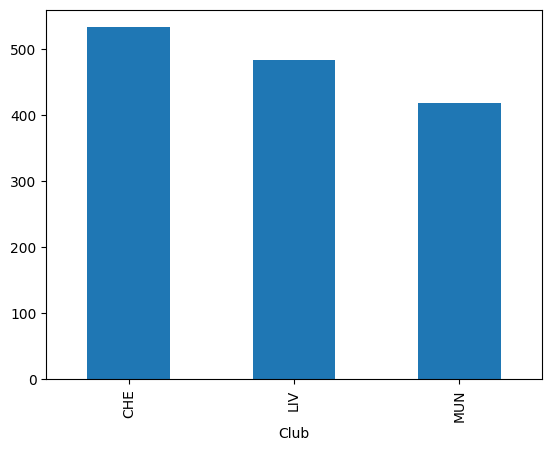

In [9]:
df.groupby('Club')['Goals'].sum().plot(kind = 'bar')
plt.xlabel('Club')
plt.show()

In [10]:
df.columns

Index(['PlayerName', 'Club', 'DistanceCovered(InKms)', 'Goals',
       'MinutestoGoalRatio', 'ShotsPerGame', 'AgentCharges', 'BMI', 'Cost',
       'PreviousClubCost', 'Height', 'Weight', 'Score'],
      dtype='object')

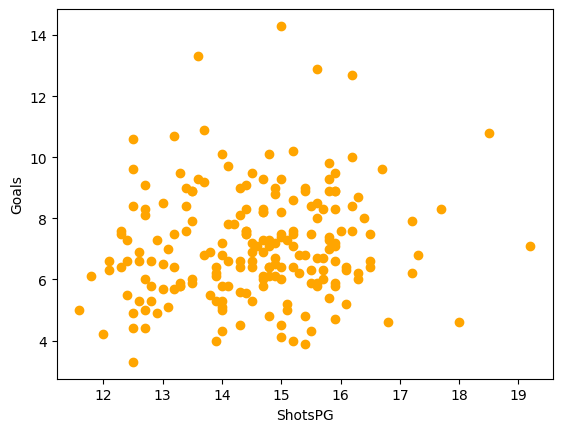

In [11]:
plt.scatter(df['ShotsPerGame'], df['Goals'], color = 'orange')
plt.xlabel('ShotsPG')
plt.ylabel('Goals')
plt.show()

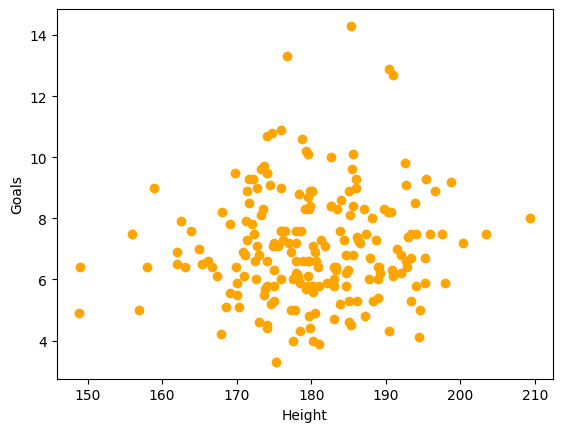

In [12]:
plt.scatter(df['Height'], df['Goals'], color = 'orange')
plt.xlabel('Height')
plt.ylabel('Goals')
plt.show()

In [13]:
import seaborn as sns


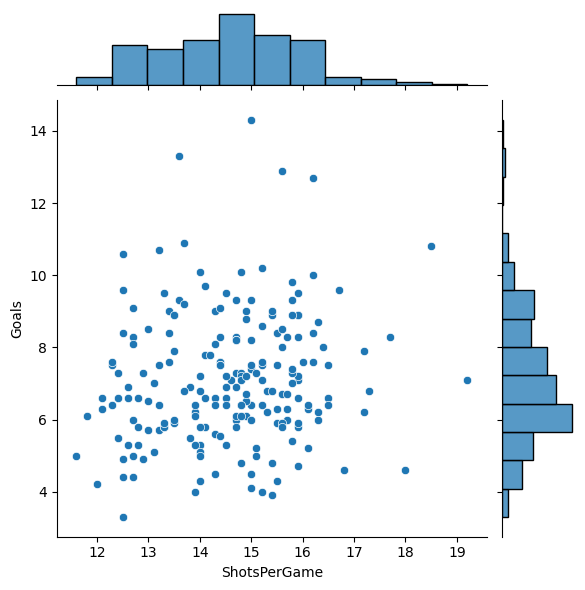

In [14]:
sns.jointplot(x = 'ShotsPerGame', y = 'Goals', data = df)

In [15]:
#Prepare data for Lin_Regression

In [16]:
corr = df.select_dtypes(include =['number']).corr()

In [17]:
corr

,DistanceCovered(InKms),Goals,MinutestoGoalRatio,ShotsPerGame,AgentCharges,BMI,Cost,PreviousClubCost,Height,Weight,Score
DistanceCovered(InKms),1.000000,0.147098,0.924964,0.888800,0.250865,0.299471,-0.403004,0.550975,0.358854,0.403743,-0.493512
Goals,0.147098,1.000000,0.153333,0.134721,0.131973,0.177032,0.137131,0.102734,0.076958,0.155844,0.108114
MinutestoGoalRatio,0.924964,0.153333,1.000000,0.950757,0.258240,0.320527,-0.449135,0.583375,0.371192,0.423699,-0.532449
ShotsPerGame,0.888800,0.134721,0.950757,1.000000,0.308391,0.382524,-0.435429,0.610986,0.352322,0.455255,-0.531522
AgentCharges,0.250865,0.131973,0.258240,0.308391,1.000000,0.302556,-0.108243,0.317581,0.123255,0.273686,-0.183386
BMI,0.299471,0.177032,0.320527,0.382524,0.302556,1.000000,0.321116,0.713858,0.337097,0.845955,0.187558
Cost,-0.403004,0.137131,-0.449135,-0.435429,-0.108243,0.321116,1.000000,-0.207749,-0.071253,0.154227,0.963017
PreviousClubCost,0.550975,0.102734,0.583375,0.610986,0.317581,0.713858,-0.207749,1.000000,0.802119,0.930904,-0.361850
Height,0.358854,0.076958,0.371192,0.352322,0.123255,0.337097,-0.071253,0.802119,1.000000,0.780906,-0.188022
Weight,0.403743,0.155844,0.423699,0.455255,0.273686,0.845955,0.154227,0.930904,0.780906,1.000000,-0.000162


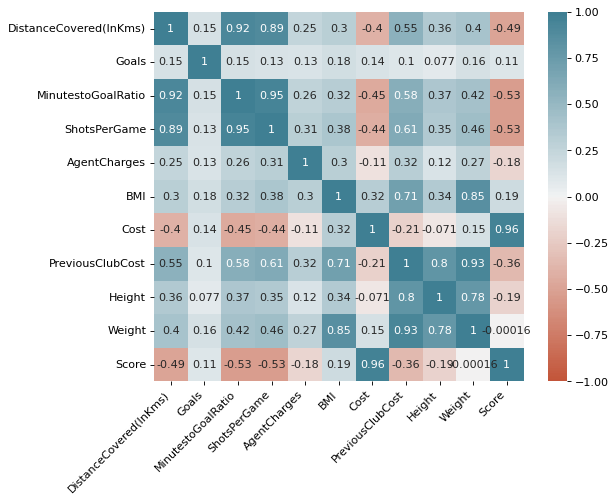

In [18]:
# Colored graph of correlations
plt.figure(figsize=(8, 6), dpi=80)
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True, annot=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

In [19]:
#PredictShotPerGames

In [20]:
df.columns

Index(['PlayerName', 'Club', 'DistanceCovered(InKms)', 'Goals',
       'MinutestoGoalRatio', 'ShotsPerGame', 'AgentCharges', 'BMI', 'Cost',
       'PreviousClubCost', 'Height', 'Weight', 'Score'],
      dtype='object')

In [21]:
data = df[['DistanceCovered(InKms)', 'MinutestoGoalRatio', 'PreviousClubCost', 'ShotsPerGame']]

In [22]:
data

,DistanceCovered(InKms),MinutestoGoalRatio,PreviousClubCost,ShotsPerGame
0,3.96,37.5,63.32,12.3
1,4.41,38.2,58.55,12.7
2,4.14,36.4,55.36,11.6
3,4.11,37.3,57.18,12.6
4,4.45,41.5,53.20,14.0
...,...,...,...,...
197,4.90,45.6,82.00,16.0
198,5.66,50.2,72.00,17.7
199,5.03,42.7,68.00,14.3
200,4.97,43.0,63.00,14.9


In [23]:
y = df['ShotsPerGame']

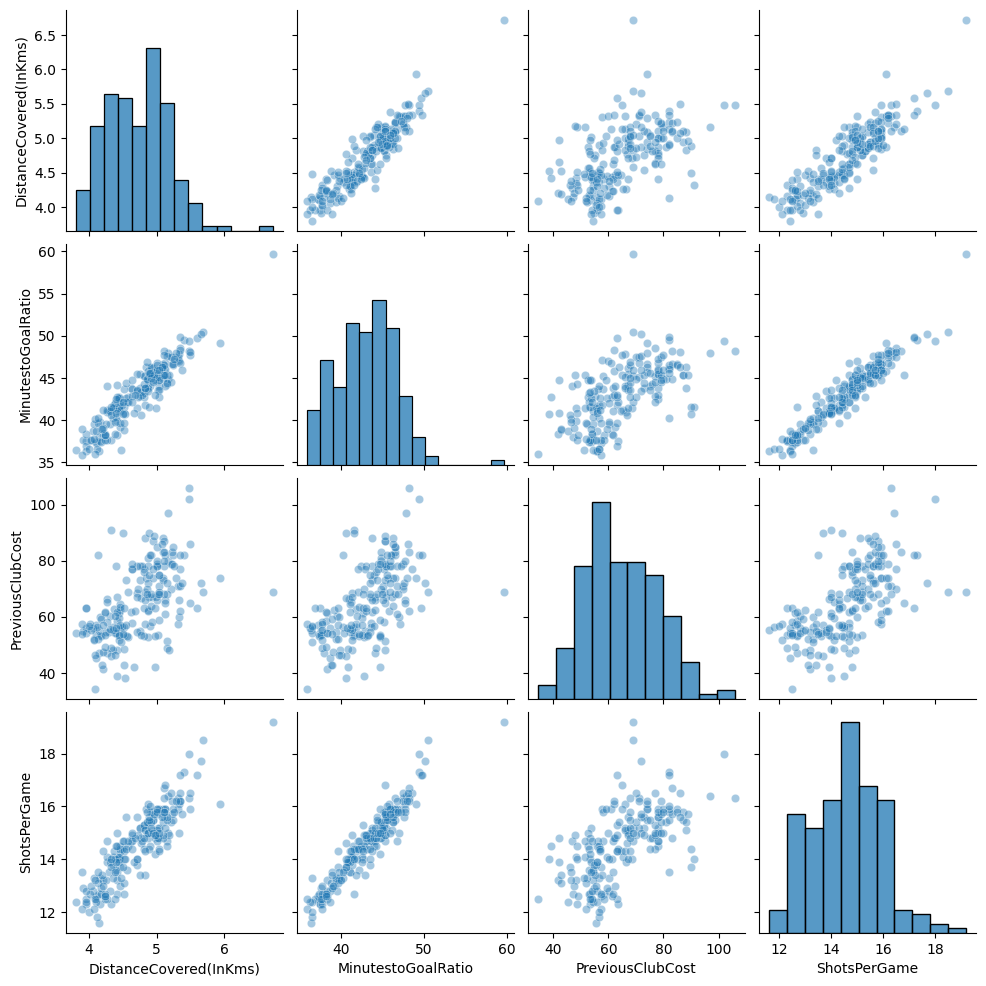

In [24]:
sns.pairplot(data, kind = 'scatter', plot_kws ={'alpha' : 0.4})

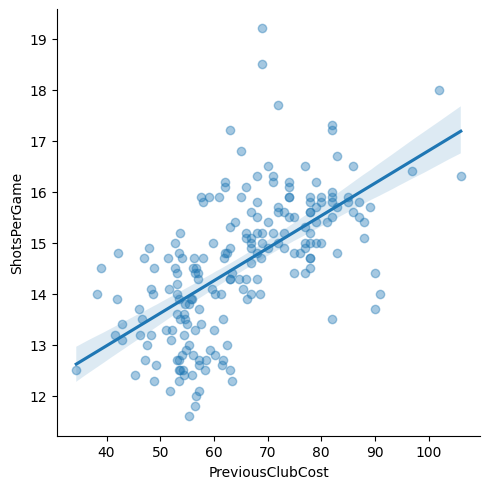

In [25]:
sns.lmplot(x = 'PreviousClubCost', y = 'ShotsPerGame', data = data, scatter_kws = {'alpha' : 0.4})

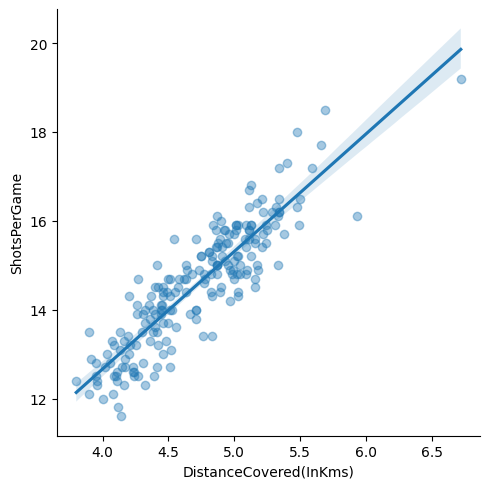

In [26]:
sns.lmplot(x = 'DistanceCovered(InKms)', y = 'ShotsPerGame', data = data, scatter_kws = {'alpha' : 0.4})

In [27]:
X = data[['DistanceCovered(InKms)', 'MinutestoGoalRatio']]
y = data['ShotsPerGame']

In [28]:
# Split Dataset:
from sklearn.model_selection import train_test_split
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)


In [29]:
X_train

,DistanceCovered(InKms),MinutestoGoalRatio
96,4.19,39.0
182,4.91,45.0
19,4.90,44.0
153,5.10,45.3
92,4.08,37.8
...,...,...
67,4.48,36.5
192,5.04,45.9
117,4.78,43.0
47,4.02,37.7


In [30]:
# LSE Method

In [31]:
X_train_n = X_train

In [32]:
X_train_n['b'] = [1] * len(X_train['MinutestoGoalRatio'])

In [33]:
X_train_n

,DistanceCovered(InKms),MinutestoGoalRatio,b
96,4.19,39.0,1
182,4.91,45.0,1
19,4.90,44.0,1
153,5.10,45.3,1
92,4.08,37.8,1
...,...,...,...
67,4.48,36.5,1
192,5.04,45.9,1
117,4.78,43.0,1
47,4.02,37.7,1


In [34]:
# LSE Algorithms 1
Theta = np.linalg.inv((X_train_n.T)@X_train_n) @ (X_train_n.T) @ y_train

In [35]:
Theta = np.array(Theta)

In [36]:
x_test_n = x_test
x_test_n['b'] = [1] * len(x_test['MinutestoGoalRatio'])

In [37]:
y_pred1 = x_test_n @ Theta

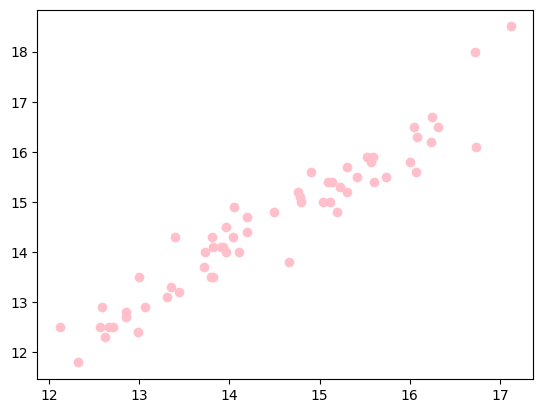

In [38]:
plt.scatter(y_pred1, y_test, color = 'pink')
plt.show()

In [39]:
Theta

array([ 0.23564223,  0.31887316, -0.32135316])

In [40]:
# Gradient Descent 2_a

In [54]:
L = 0.0001
erochs = 120000
w = [0.0, 0.0, 0.0]
n = len(X_train_n['MinutestoGoalRatio'])
for _ in range(erochs):
    y_pred = X_train_n @ w
    error = y_pred - y_train
    grad = (2/n)*(X_train_n.T)@ error
    w = w - L*grad
print(w)

DistanceCovered(InKms)    0.144649
MinutestoGoalRatio        0.322571
b                        -0.047953
dtype: float64


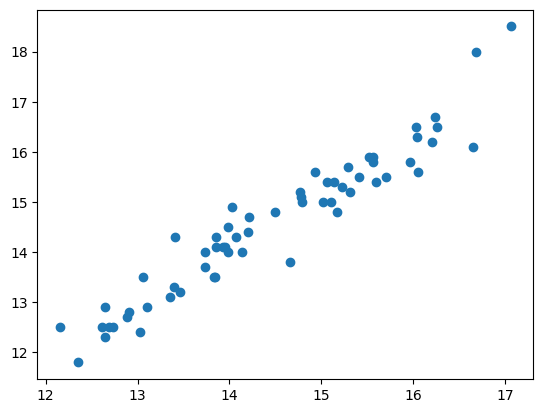

In [55]:
y_pred2 = x_test_n @ w
plt.scatter(y_pred2, y_test)
plt.show()

In [58]:
# Gradien Descent 2_b


In [74]:
from sklearn.model_selection import train_test_split
X1_train, x1_test, y1_train, y1_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [75]:
X1_train

,DistanceCovered(InKms),MinutestoGoalRatio
96,4.19,39.0
182,4.91,45.0
19,4.90,44.0
153,5.10,45.3
92,4.08,37.8
...,...,...
67,4.48,36.5
192,5.04,45.9
117,4.78,43.0
47,4.02,37.7


In [79]:
L = 0.0001
n = len(X1_train['MinutestoGoalRatio'])
b = 0.0  # Initialize b as a scalar
t = np.array([0.0, 0.0]) # Initialize t as a numpy array for element-wise operations
erochs = 100000

for _ in range(erochs):
    y1_pre = X1_train @ t + b
    error = y1_pre - y1_train
    t_grad = (2/n) * (X1_train.T) @ error
    b_grad = (2/n) * np.sum(error) # Sum the error for the scalar bias gradient
    t -= L * t_grad
    b -= L * b_grad

print(f"Learned coefficients (t): {t}")
print(f"Learned intercept (b): {b}")

Learned coefficients (t): DistanceCovered(InKms)    0.131668
MinutestoGoalRatio        0.323802
dtype: float64
Learned intercept (b): -0.03953655002587709


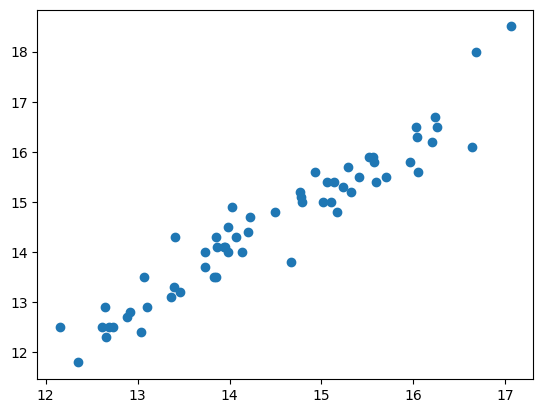

In [80]:
Y1_pred = x1_test @ t + b
plt.scatter(Y1_pred, y1_test)
plt.show()

In [84]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [87]:
MSE = mean_squared_error(y1_test, Y1_pred)
MVE = mean_absolute_error(y1_test, Y1_pred)
print(MSE, MVE)

0.19285666286774725 0.34178269643677095
